# Analyse des résidus médicamenteux en Nouvelle-Aquitaine
##  Objectif du notebook

Ce notebook présente les étapes de préparation, nettoyage, fusion et structuration des données utilisées pour construire le dashboard Power BI de surveillance des résidus médicamenteux dans les eaux de surface en Nouvelle-Aquitaine.

L’objectif est de transformer des données environnementales issues de NAIADES en une base analytique exploitable pour l’analyse spatio-temporelle des concentrations de résidus médicamenteux.


In [1]:
import pandas as pd

# Charger le fichier
df = pd.read_csv("Analyses.CSV", sep=";", encoding="utf-8")

# Aperçu général
print("Dimensions du dataset :", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())

display(df.head())
display(df.tail())

   

Dimensions du dataset : (1626, 51)

Colonnes disponibles :
['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'CdSupport', 'LbSupport', 'CdFractionAnalysee', 'LbFractionAnalysee', 'CdPrelevement', 'DatePrel', 'HeurePrel', 'DateAna', 'HeureAna', 'CdParametre', 'LbLongParamètre', 'RsAna', 'CdUniteMesure', 'SymUniteMesure', 'CdRqAna', 'MnemoRqAna', 'CdInsituAna', 'LbInsituAna', 'ProfondeurPrel', 'CdDifficulteAna', 'MnemoDifficulteAna', 'LdAna', 'LqAna', 'LsAna', 'IncertAna', 'CdMetFractionnement', 'NomMetFractionnement', 'CdMethode', 'NomMethode', 'RdtExtraction', 'CdMethodeExtraction', 'NomMethodeExtraction', 'CdAccreAna', 'MnemoAccredAna', 'AgreAna', 'CdStatutAna', 'MnemoStatutAna', 'CdQualAna', 'LbQualAna', 'CommentairesAna', 'ComResultatAna', 'CdRdd', 'NomRdd', 'CdProducteur', 'NomProducteur', 'CdPreleveur', 'NomPreleveur', 'CdLaboratoire', 'NomLaboratoire']


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,CdSupport,LbSupport,CdFractionAnalysee,LbFractionAnalysee,CdPrelevement,DatePrel,HeurePrel,DateAna,...,CommentairesAna,ComResultatAna,CdRdd,NomRdd,CdProducteur,NomProducteur,CdPreleveur,NomPreleveur,CdLaboratoire,NomLaboratoire
0,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
1,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
2,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
3,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
4,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090845-PC-383689,2015-05-11,12:30:00,2015-05-11,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,CdSupport,LbSupport,CdFractionAnalysee,LbFractionAnalysee,CdPrelevement,DatePrel,HeurePrel,DateAna,...,CommentairesAna,ComResultatAna,CdRdd,NomRdd,CdProducteur,NomProducteur,CdPreleveur,NomPreleveur,CdLaboratoire,NomLaboratoire
1621,L451510,ETANG DE LA GRANDE CAZINE à NOTH,3,Eau,23,Eau brute,20181221103448-PC-387935,2015-09-23,10:00:00,2015-09-23,...,Perte de sensibilité temporaire de la méthode ...,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,43796067700098,ASCONIT CONSULTANTS,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
1622,L451510,ETANG DE LA GRANDE CAZINE à NOTH,3,Eau,23,Eau brute,20181221103448-PC-387935,2015-09-23,10:00:00,2015-09-23,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,43796067700098,ASCONIT CONSULTANTS,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
1623,L451510,ETANG DE LA GRANDE CAZINE à NOTH,3,Eau,23,Eau brute,20181221103448-PC-387935,2015-09-23,10:00:00,2015-09-23,...,NaN,NaN,NaN,NaN,104,Agence de l'Eau Loire-Bretagne,43796067700098,ASCONIT CONSULTANTS,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
1624,Q3325003,Barrage de l'Ayguelongue,3,Eau,23,Eau brute,1453433,2017-06-01,11:50:00,NaN,...,NaN,NaN,0500000077,Contrôles opérationnels des plans d'eau du bas...,18310006400033,AGENCE DE L'EAU ADOUR GARONNE,41749411900056,AQUABIO,75680009000257,EUROFINS HYDROLOGIE EST
1625,Q3325003,Barrage de l'Ayguelongue,3,Eau,23,Eau brute,1453506,2017-10-05,09:10:00,NaN,...,NaN,NaN,0500000077,Contrôles opérationnels des plans d'eau du bas...,18310006400033,AGENCE DE L'EAU ADOUR GARONNE,41749411900056,AQUABIO,75680009000257,EUROFINS HYDROLOGIE EST


In [2]:
# 3. Conversion des dates
df["DatePrel"] = pd.to_datetime(df["DatePrel"], errors="coerce")

In [3]:
# 4. Résumé utile pour la partie 'Les données'
nombre_observations = df.shape[0]
nombre_stations = df["LbStationMesureEauxSurface"].nunique()
nombre_prelevements = df["CdPrelevement"].nunique()
medicaments = df["LbLongParamètre"].unique()
periode_min = df["DatePrel"].min()
periode_max = df["DatePrel"].max()
unites = df["SymUniteMesure"].unique()

print("\n--- Résumé du jeu de données ---")
print(f"Nombre total d'analyses : {nombre_observations}")
print(f"Nombre de stations de mesure : {nombre_stations}")
print(f"Nombre de prélèvements : {nombre_prelevements}")
print(f"Période couverte : de {periode_min.date()} à {periode_max.date()}")
print(f"Substances analysées : {', '.join(medicaments)}")
print(f"Unités de mesure : {', '.join(unites)}")


--- Résumé du jeu de données ---
Nombre total d'analyses : 1626
Nombre de stations de mesure : 229
Nombre de prélèvements : 820
Période couverte : de 2015-03-05 à 2024-12-23
Substances analysées : Diclofenac, Ibuprofene, Paracetamol, Sulfamethoxazole
Unités de mesure : µg/L


In [4]:

# 5. Nombre d'analyses par médicament
print("\nNombre d'analyses par médicament :")
print(df["LbLongParamètre"].value_counts())




Nombre d'analyses par médicament :
LbLongParamètre
Paracetamol         602
Diclofenac          476
Sulfamethoxazole    413
Ibuprofene          135
Name: count, dtype: int64


#  Aperçu des données importantes
colonnes_utiles = [
     "LbStationMesureEauxSurface",
    "DatePrel",
    "LbLongParamètre",
    "RsAna",
    "SymUniteMesure",
    "LbQualAna"
]

df[colonnes_utiles].head()

In [5]:
# Charger la base stations
stations = pd.read_csv("Stations.CSV", sep=";", encoding="utf-8")

# Vérifier les colonnes
print(stations.shape)
print(stations.columns.tolist())
stations.head()

(229, 39)
['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'DurStationMesureEauxSurface', 'CoordXStationMesureEauxSurface', 'CoordYStationMesureEauxSurface', 'CdProjStationMesureEauxSurface', 'LibelleProjection', 'CodeCommune', 'LbCommune', 'CodeDepartement', 'LbDepartement', 'CodeRegion', 'LbRegion', 'CdMasseDEau', 'CdEuMasseDEau', 'NomMasseDEau', 'CdEuSsBassinDCEAdmin', 'NomSsBassinDCEAdmin', 'CdBassinDCE', 'CdEuBassinDCE', 'NomEuBassinDCE', 'CdTronconHydrographique', 'CdCoursdEau', 'NomCoursdEau', 'CodeTypEthStationMesureEauxSurface', 'LibelleTypEthStationMesureEauxSurface', 'ComStationMesureEauxSurface', 'DateCreationStationMesureEauxSurface', 'DateArretActiviteStationMesureEauxSurface', 'DateMAJInfosStationMesureEauxSurface', 'FinaliteStationMesureEauxSurface', 'LocPreciseStationMesureEauxSurface', 'CodeNatureStationMesureEauxSurface', 'LibelleNatureStationMesureEauxSurface', 'AltitudePointCaracteritisque', 'PkPointTronconEntiteHydroPrincipale', 'PremierMoisAnneeEtiage

,CdStationMesureEauxSurface,LbStationMesureEauxSurface,DurStationMesureEauxSurface,CoordXStationMesureEauxSurface,CoordYStationMesureEauxSurface,CdProjStationMesureEauxSurface,LibelleProjection,CodeCommune,LbCommune,CodeDepartement,...,DateMAJInfosStationMesureEauxSurface,FinaliteStationMesureEauxSurface,LocPreciseStationMesureEauxSurface,CodeNatureStationMesureEauxSurface,LibelleNatureStationMesureEauxSurface,AltitudePointCaracteritisque,PkPointTronconEntiteHydroPrincipale,PremierMoisAnneeEtiage,SuperficieBassinVersantReel,SuperficieBassinVersantTopo
0,04057000,CHER à CHAMBONCHARD,NaN,666521.90,6560580.00,26,RGF93 / Lambert 93,23046,Chambonchard,23,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN
1,04057700,TARDES à TARDES,NaN,649340.28,6560042.65,26,RGF93 / Lambert 93,23251,Tardes,23,...,2011-01-10,Non renseigné,TARDES ...,M,Station de mesure Manuelle,379,NaN,NaN,NaN,NaN
2,04057740,GOZE À GOUZON,NaN,636324.10,6563471.00,26,RGF93 / Lambert 93,23093,Gouzon,23,...,2011-01-10,Non renseigné,LE LONG DE LA D65 ...,M,Station de mesure Manuelle,419,NaN,NaN,NaN,NaN
3,04057750,VOUEIZE à LUSSAT,NaN,647550.52,6567968.87,26,RGF93 / Lambert 93,23114,Lussat,23,...,2001-02-28,Non renseigné,HAUTE RIVE ...,M,Station de mesure Manuelle,363,984685.0,NaN,NaN,NaN
4,04075882,COMBADE à SAINT-DENIS-DES-MURS,NaN,587577.60,6521630.00,26,RGF93 / Lambert 93,87142,Saint-Denis-des-Murs,87,...,2010-06-08,Non renseigné,PONT DE LA D123 ...,M,Station de mesure Manuelle,295,NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'CdSupport',
       'LbSupport', 'CdFractionAnalysee', 'LbFractionAnalysee',
       'CdPrelevement', 'DatePrel', 'HeurePrel', 'DateAna', 'HeureAna',
       'CdParametre', 'LbLongParamètre', 'RsAna', 'CdUniteMesure',
       'SymUniteMesure', 'CdRqAna', 'MnemoRqAna', 'CdInsituAna', 'LbInsituAna',
       'ProfondeurPrel', 'CdDifficulteAna', 'MnemoDifficulteAna', 'LdAna',
       'LqAna', 'LsAna', 'IncertAna', 'CdMetFractionnement',
       'NomMetFractionnement', 'CdMethode', 'NomMethode', 'RdtExtraction',
       'CdMethodeExtraction', 'NomMethodeExtraction', 'CdAccreAna',
       'MnemoAccredAna', 'AgreAna', 'CdStatutAna', 'MnemoStatutAna',
       'CdQualAna', 'LbQualAna', 'CommentairesAna', 'ComResultatAna', 'CdRdd',
       'NomRdd', 'CdProducteur', 'NomProducteur', 'CdPreleveur',
       'NomPreleveur', 'CdLaboratoire', 'NomLaboratoire'],
      dtype='object')

In [7]:
stations.columns

Index(['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface',
       'DurStationMesureEauxSurface', 'CoordXStationMesureEauxSurface',
       'CoordYStationMesureEauxSurface', 'CdProjStationMesureEauxSurface',
       'LibelleProjection', 'CodeCommune', 'LbCommune', 'CodeDepartement',
       'LbDepartement', 'CodeRegion', 'LbRegion', 'CdMasseDEau',
       'CdEuMasseDEau', 'NomMasseDEau', 'CdEuSsBassinDCEAdmin',
       'NomSsBassinDCEAdmin', 'CdBassinDCE', 'CdEuBassinDCE', 'NomEuBassinDCE',
       'CdTronconHydrographique', 'CdCoursdEau', 'NomCoursdEau',
       'CodeTypEthStationMesureEauxSurface',
       'LibelleTypEthStationMesureEauxSurface', 'ComStationMesureEauxSurface',
       'DateCreationStationMesureEauxSurface',
       'DateArretActiviteStationMesureEauxSurface',
       'DateMAJInfosStationMesureEauxSurface',
       'FinaliteStationMesureEauxSurface',
       'LocPreciseStationMesureEauxSurface',
       'CodeNatureStationMesureEauxSurface',
       'LibelleNatureStationMesure

In [8]:
# Fusion des bases
df_complet = df.merge(
    stations,
    on="CdStationMesureEauxSurface",
    how="left"
)

print(df_complet.shape)
df_complet.head()

(1626, 89)


,CdStationMesureEauxSurface,LbStationMesureEauxSurface_x,CdSupport,LbSupport,CdFractionAnalysee,LbFractionAnalysee,CdPrelevement,DatePrel,HeurePrel,DateAna,...,DateMAJInfosStationMesureEauxSurface,FinaliteStationMesureEauxSurface,LocPreciseStationMesureEauxSurface,CodeNatureStationMesureEauxSurface,LibelleNatureStationMesureEauxSurface,AltitudePointCaracteritisque,PkPointTronconEntiteHydroPrincipale,PremierMoisAnneeEtiage,SuperficieBassinVersantReel,SuperficieBassinVersantTopo
0,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN
1,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN
2,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN
3,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090833-PC-383683,2015-06-09,12:40:00,2015-06-09,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN
4,04057000,CHER à CHAMBONCHARD,3,Eau,23,Eau brute,20181221090845-PC-383689,2015-05-11,12:30:00,2015-05-11,...,2010-06-07,Non renseigné,PONT DE RAMEAU ...,M,Station de mesure Manuelle,365,NaN,NaN,NaN,NaN


In [9]:
df_complet.columns

Index(['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface_x',
       'CdSupport', 'LbSupport', 'CdFractionAnalysee', 'LbFractionAnalysee',
       'CdPrelevement', 'DatePrel', 'HeurePrel', 'DateAna', 'HeureAna',
       'CdParametre', 'LbLongParamètre', 'RsAna', 'CdUniteMesure',
       'SymUniteMesure', 'CdRqAna', 'MnemoRqAna', 'CdInsituAna', 'LbInsituAna',
       'ProfondeurPrel', 'CdDifficulteAna', 'MnemoDifficulteAna', 'LdAna',
       'LqAna', 'LsAna', 'IncertAna', 'CdMetFractionnement',
       'NomMetFractionnement', 'CdMethode', 'NomMethode', 'RdtExtraction',
       'CdMethodeExtraction', 'NomMethodeExtraction', 'CdAccreAna',
       'MnemoAccredAna', 'AgreAna', 'CdStatutAna', 'MnemoStatutAna',
       'CdQualAna', 'LbQualAna', 'CommentairesAna', 'ComResultatAna', 'CdRdd',
       'NomRdd', 'CdProducteur', 'NomProducteur', 'CdPreleveur',
       'NomPreleveur', 'CdLaboratoire', 'NomLaboratoire',
       'LbStationMesureEauxSurface_y', 'DurStationMesureEauxSurface',
       'CoordXS

In [10]:
colonnes_utiles = [

    # Identification station
    "CdStationMesureEauxSurface",
    "LbStationMesureEauxSurface_x",

    # Localisation
    "LbCommune",
    "LbRegion",
    "CodeDepartement",
    "LbDepartement",

    # Coordonnées
    "CoordXStationMesureEauxSurface",
    "CoordYStationMesureEauxSurface",

    # Date
    "DatePrel",

    # Médicament
    "LbLongParamètre",

    # Concentration
    "RsAna",

    # Unité
    "SymUniteMesure",

    # Qualité analyse
    "LbQualAna"
]

# Création de la base projet
df_projet = df_complet[colonnes_utiles]

# Renommage des colonnes
df_projet = df_projet.rename(columns={

    "CdStationMesureEauxSurface": "code_station",
    "LbStationMesureEauxSurface_x": "station",

    "LbCommune": "commune",
    "LbRegion": "region",
    "LbDepartement": "departement",
    

    "CoordXStationMesureEauxSurface": "x",
    "CoordYStationMesureEauxSurface": "y",

    "DatePrel": "date_prelevement",

    "LbLongParamètre": "medicament",

    "RsAna": "concentration",

    "SymUniteMesure": "unite",

    "LbQualAna": "qualite_analyse"
})

# Aperçu
print(df_projet.head())

# Informations générales
print(df_projet.info())

# Valeurs manquantes
print(df_projet.isnull().sum())

  code_station              station       commune              region  \
0     04057000  CHER à CHAMBONCHARD  Chambonchard  Nouvelle-Aquitaine   
1     04057000  CHER à CHAMBONCHARD  Chambonchard  Nouvelle-Aquitaine   
2     04057000  CHER à CHAMBONCHARD  Chambonchard  Nouvelle-Aquitaine   
3     04057000  CHER à CHAMBONCHARD  Chambonchard  Nouvelle-Aquitaine   
4     04057000  CHER à CHAMBONCHARD  Chambonchard  Nouvelle-Aquitaine   

   CodeDepartement departement         x          y date_prelevement  \
0               23      Creuse  666521.9  6560580.0       2015-06-09   
1               23      Creuse  666521.9  6560580.0       2015-06-09   
2               23      Creuse  666521.9  6560580.0       2015-06-09   
3               23      Creuse  666521.9  6560580.0       2015-06-09   
4               23      Creuse  666521.9  6560580.0       2015-05-11   

         medicament  concentration unite qualite_analyse  
0        Diclofenac           0.02  µg/L        Correcte  
1        I

In [11]:
# Compréhension des valeurs manquantes
df_projet["qualite_analyse"].value_counts()

qualite_analyse
Correcte    1626
Name: count, dtype: int64

In [12]:
df_projet[df_projet["concentration"].isnull()][
    ["medicament", "qualite_analyse"]
].head(20)

,medicament,qualite_analyse
84,Diclofenac,Correcte
85,Paracetamol,Correcte
86,Sulfamethoxazole,Correcte
87,Diclofenac,Correcte
88,Paracetamol,Correcte
89,Sulfamethoxazole,Correcte
90,Diclofenac,Correcte
91,Paracetamol,Correcte
92,Sulfamethoxazole,Correcte
93,Diclofenac,Correcte


Les valeurs manquantes ne viennent pas de :

la qualité d’analyse,
une erreur laboratoire,
ou des analyses invalides.

In [13]:
df_projet[df_projet["concentration"].isnull()].head(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse
84,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-04-05,Diclofenac,NaN,µg/L,Correcte
85,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-04-05,Paracetamol,NaN,µg/L,Correcte
86,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-04-05,Sulfamethoxazole,NaN,µg/L,Correcte
87,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-05-04,Diclofenac,NaN,µg/L,Correcte
88,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-05-04,Paracetamol,NaN,µg/L,Correcte
89,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-05-04,Sulfamethoxazole,NaN,µg/L,Correcte
90,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-06-06,Diclofenac,NaN,µg/L,Correcte
91,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-06-06,Paracetamol,NaN,µg/L,Correcte
92,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-06-06,Sulfamethoxazole,NaN,µg/L,Correcte
93,04075990,TARD À SAINT-LEONARD-DE-NOBLAT,Saint-Léonard-de-Noblat,Nouvelle-Aquitaine,87,Haute-Vienne,581533.1,6529555.0,2023-07-05,Diclofenac,NaN,µg/L,Correcte


In [14]:
df_projet[df_projet["concentration"].isnull()].tail(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse
1112,04554003,RAU DE L'ETANG ROMPU A PINDRAY,Pindray,Nouvelle-Aquitaine,86,Vienne,533514.8,6600500.0,2023-11-10,Diclofenac,NaN,µg/L,Correcte
1113,04554003,RAU DE L'ETANG ROMPU A PINDRAY,Pindray,Nouvelle-Aquitaine,86,Vienne,533514.8,6600500.0,2023-11-10,Paracetamol,NaN,µg/L,Correcte
1114,04554003,RAU DE L'ETANG ROMPU A PINDRAY,Pindray,Nouvelle-Aquitaine,86,Vienne,533514.8,6600500.0,2023-11-10,Sulfamethoxazole,NaN,µg/L,Correcte
1115,04583002,RUAUX À BOUILLÉ-LORETZ,Loretz-d'Argenton,Nouvelle-Aquitaine,79,Deux-Sèvres,456173.1,6671348.0,2022-12-22,Ibuprofene,NaN,µg/L,Correcte
1116,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-04-14,Diclofenac,NaN,µg/L,Correcte
1117,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-04-14,Paracetamol,NaN,µg/L,Correcte
1118,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-04-14,Sulfamethoxazole,NaN,µg/L,Correcte
1119,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-05-23,Diclofenac,NaN,µg/L,Correcte
1120,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-05-23,Paracetamol,NaN,µg/L,Correcte
1121,04760004,RAU COURANCE A MARIGNY,Marigny,Nouvelle-Aquitaine,79,Deux-Sèvres,435410.6,6573796.0,2023-05-23,Sulfamethoxazole,NaN,µg/L,Correcte


In [15]:
df[df["RsAna"].isnull()][[
    "RsAna",
    "CdRqAna",
    "LbQualAna",
    "ComResultatAna"
]].head(20)

,RsAna,CdRqAna,LbQualAna,ComResultatAna
84,NaN,0,Correcte,NaN
85,NaN,0,Correcte,NaN
86,NaN,0,Correcte,NaN
87,NaN,0,Correcte,NaN
88,NaN,0,Correcte,NaN
89,NaN,0,Correcte,NaN
90,NaN,0,Correcte,NaN
91,NaN,0,Correcte,NaN
92,NaN,0,Correcte,NaN
93,NaN,0,Correcte,NaN


Traitement des valeurs manquantes

Lors de l’exploration des données, certaines observations présentaient des valeurs manquantes pour la variable de concentration (RsAna). L’analyse du code remarque physico-chimique (CdRqAna) a montré que ces valeurs correspondaient principalement au code 0, associé à une analyse non faite.

Ces valeurs manquantes ne résultent donc pas d’une erreur de traitement ou de fusion des données, mais d’analyses non réalisées ou ne fournissant pas de résultat exploitable.

Dans le cadre de cette étude exploratoire, ces observations ont été supprimées afin de conserver uniquement les analyses quantitatives exploitables

In [16]:
# transformation du code remarque
codes_remarques = {
    0: "Analyse non faite",
    1: "Domaine de validité",
    2: "Inférieur au seuil de détection",
    3: "Supérieur au seuil de saturation",
    4: "Présence ou absence",
    5: "Incomptable",
    6: "Taxons non individualisables",
    7: "Traces",
    8: "Dénombrement supérieur à la valeur",
    9: "Dénombrement inférieur à la valeur",
    10: "Inférieur au seuil de quantification"
}

df_projet["remarque_analyse"] = df["CdRqAna"].map(codes_remarques)

df_projet[[
    "medicament",
    "concentration",
    "remarque_analyse"
]].head(20)


,medicament,concentration,remarque_analyse
0,Diclofenac,0.020,Inférieur au seuil de quantification
1,Ibuprofene,0.050,Inférieur au seuil de quantification
2,Paracetamol,0.300,Inférieur au seuil de quantification
3,Sulfamethoxazole,0.020,Inférieur au seuil de quantification
4,Diclofenac,0.020,Inférieur au seuil de quantification
5,Ibuprofene,0.050,Inférieur au seuil de quantification
6,Paracetamol,0.300,Inférieur au seuil de quantification
7,Sulfamethoxazole,0.020,Inférieur au seuil de quantification
8,Diclofenac,0.020,Inférieur au seuil de quantification
9,Ibuprofene,0.050,Inférieur au seuil de quantification


In [17]:
df_projet["remarque_analyse"].value_counts()

remarque_analyse
Inférieur au seuil de quantification    575
Analyse non faite                       560
Domaine de validité                     491
Name: count, dtype: int64

Traitement des valeurs manquantes et interprétation des codes d’analyse

L’exploration de la variable CdRqAna, correspondant au code remarque des analyses physico-chimiques, a permis d’identifier trois principales catégories de résultats :
des analyses appartenant au domaine de validité ;
des résultats inférieurs au seuil de quantification ;
des analyses non faites.

Les valeurs manquantes observées pour la concentration (RsAna) correspondaient principalement aux analyses non réalisées (CdRqAna = 0)
Ces observations ne résultent donc pas d’une erreur de traitement des données mais d’analyses sans résultat exploitable.

Dans le cadre de cette étude exploratoire, ces observations 
ont été supprimées afin de conserver uniquement les mesures quantitatives exploitables pour l’analyse des concentrations de résidus médicamenteux.

df_quantif : uniquement les vraies concentrations exploitables
df_detect : pour analyser aussi les résultats sous seuil de quantification plus tard

In [18]:
# Base quantitative : uniquement les résultats dans le domaine de validité
df_quantif = df_projet[
    df_projet["remarque_analyse"] == "Domaine de validité"
].copy()

print(df_quantif.shape)
df_quantif.head()

(491, 14)


,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse
41,04057750,VOUEIZE à LUSSAT,Lussat,Nouvelle-Aquitaine,23,Creuse,647550.52,6567968.87,2015-11-05,Diclofenac,0.032,µg/L,Correcte,Domaine de validité
43,04057750,VOUEIZE à LUSSAT,Lussat,Nouvelle-Aquitaine,23,Creuse,647550.52,6567968.87,2015-10-07,Diclofenac,0.121,µg/L,Correcte,Domaine de validité
45,04057750,VOUEIZE à LUSSAT,Lussat,Nouvelle-Aquitaine,23,Creuse,647550.52,6567968.87,2015-12-07,Diclofenac,0.052,µg/L,Correcte,Domaine de validité
63,04075882,COMBADE à SAINT-DENIS-DES-MURS,Saint-Denis-des-Murs,Nouvelle-Aquitaine,87,Haute-Vienne,587577.60,6521630.00,2022-02-08,Paracetamol,3.325,µg/L,Correcte,Domaine de validité
119,04076420,TAURION à SAINT-HILAIRE-LE-CHATEAU,Saint-Hilaire-le-Château,Nouvelle-Aquitaine,23,Creuse,612316.90,6543747.00,2023-08-24,Diclofenac,0.214,µg/L,Correcte,Domaine de validité


In [19]:
df_quantif["remarque_analyse"].value_counts()

remarque_analyse
Domaine de validité    491
Name: count, dtype: int64

In [20]:
df_quantif["concentration"].isnull().sum()

np.int64(0)

In [21]:
print("Nombre d'analyses quantitatives :", df_quantif.shape[0])
print("Nombre de stations :", df_quantif["code_station"].nunique())
print("Nombre de communes :", df_quantif["commune"].nunique())
print("Période :", df_quantif["date_prelevement"].min(), "à", df_quantif["date_prelevement"].max())
print("Médicaments :", df_quantif["medicament"].unique())

Nombre d'analyses quantitatives : 491
Nombre de stations : 164
Nombre de communes : 151
Période : 2015-04-08 00:00:00 à 2024-09-18 00:00:00
Médicaments : ['Diclofenac' 'Paracetamol' 'Sulfamethoxazole' 'Ibuprofene']


# Distribution des médicaments

In [22]:
df_quantif["medicament"].value_counts()

medicament
Paracetamol         201
Diclofenac          132
Sulfamethoxazole    130
Ibuprofene           28
Name: count, dtype: int64

In [23]:
df_quantif[df_quantif["medicament"] == "Paracetamol"] \
    .sort_values(by="concentration", ascending=False) \
    .head(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse
1290,05052000,La Vézère en aval de la Corrèze,Terrasson-Lavilledieu,Nouvelle-Aquitaine,24,Dordogne,566946.0,6449240.0,2019-09-19,Paracetamol,2300.000,µg/L,Correcte,Domaine de validité
1409,05077675,Le Ruisseau de Brion à Langon,Langon,Nouvelle-Aquitaine,33,Gironde,442114.0,6388080.0,2022-06-21,Paracetamol,21.000,µg/L,Correcte,Domaine de validité
1403,05075257,Le ruisseau de Lubert au niveau de Saint-Genès...,Saint-Genès-de-Lombaud,Nouvelle-Aquitaine,33,Gironde,434735.0,6412200.0,2022-11-24,Paracetamol,8.259,µg/L,Correcte,Domaine de validité
121,04076980,LE VERGER A BOURGANEUF,Bourganeuf,Nouvelle-Aquitaine,23,Creuse,603310.2,6539694.0,2024-07-26,Paracetamol,7.899,µg/L,Correcte,Domaine de validité
1254,05037000,L'Isle à St-Antoine,Saint-Antoine-sur-l'Isle,Nouvelle-Aquitaine,33,Gironde,466841.0,6440500.0,2020-07-21,Paracetamol,7.000,µg/L,Correcte,Domaine de validité
1221,05025598,Les Martinettes au niveau d'Etauliers,Étauliers,Nouvelle-Aquitaine,33,Gironde,421022.0,6463700.0,2021-10-18,Paracetamol,5.000,µg/L,Correcte,Domaine de validité
1297,05053000,La Corrèze à l'aval de Brive,Saint-Pantaléon-de-Larche,Nouvelle-Aquitaine,19,Corrèze,579091.0,6453140.0,2018-05-14,Paracetamol,4.100,µg/L,Correcte,Domaine de validité
1366,05074500,L'Eau Bourde à Bègles,Bègles,Nouvelle-Aquitaine,33,Gironde,418194.0,6416250.0,2020-08-27,Paracetamol,4.000,µg/L,Correcte,Domaine de validité
1294,05053000,La Corrèze à l'aval de Brive,Saint-Pantaléon-de-Larche,Nouvelle-Aquitaine,19,Corrèze,579091.0,6453140.0,2017-09-18,Paracetamol,3.800,µg/L,Correcte,Domaine de validité
63,04075882,COMBADE à SAINT-DENIS-DES-MURS,Saint-Denis-des-Murs,Nouvelle-Aquitaine,87,Haute-Vienne,587577.6,6521630.0,2022-02-08,Paracetamol,3.325,µg/L,Correcte,Domaine de validité


In [24]:
df_quantif[df_quantif["medicament"] == "Diclofenac"] \
    .sort_values(by="concentration", ascending=False) \
    .head(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse
1401,05075257,Le ruisseau de Lubert au niveau de Saint-Genès...,Saint-Genès-de-Lombaud,Nouvelle-Aquitaine,33,Gironde,434735.0,6412200.0,2022-09-22,Diclofenac,0.511,µg/L,Correcte,Domaine de validité
1220,05025598,Les Martinettes au niveau d'Etauliers,Étauliers,Nouvelle-Aquitaine,33,Gironde,421022.0,6463700.0,2021-10-18,Diclofenac,0.483,µg/L,Correcte,Domaine de validité
1271,05043300,La Loue au Moulin des Jalladas,Saint-Yrieix-la-Perche,Nouvelle-Aquitaine,87,Haute-Vienne,557684.0,6489830.0,2018-09-18,Diclofenac,0.380,µg/L,Correcte,Domaine de validité
1340,05068400,La Luzège en amont de Laval,Laval-sur-Luzège,Nouvelle-Aquitaine,19,Corrèze,634779.0,6461940.0,2024-07-22,Diclofenac,0.380,µg/L,Correcte,Domaine de validité
1407,05077675,Le Ruisseau de Brion à Langon,Langon,Nouvelle-Aquitaine,33,Gironde,442114.0,6388080.0,2018-10-22,Diclofenac,0.367,µg/L,Correcte,Domaine de validité
1346,05068470,Le R. d'Egletons en aval d'Egletons,Darnets,Nouvelle-Aquitaine,19,Corrèze,627928.0,6479940.0,2024-07-22,Diclofenac,0.320,µg/L,Correcte,Domaine de validité
1362,05074500,L'Eau Bourde à Bègles,Bègles,Nouvelle-Aquitaine,33,Gironde,418194.0,6416250.0,2017-10-23,Diclofenac,0.300,µg/L,Correcte,Domaine de validité
119,04076420,TAURION à SAINT-HILAIRE-LE-CHATEAU,Saint-Hilaire-le-Château,Nouvelle-Aquitaine,23,Creuse,612316.9,6543747.0,2023-08-24,Diclofenac,0.214,µg/L,Correcte,Domaine de validité
311,04086500,VIENNE à PORT-DE-PILES,Port-de-Piles,Nouvelle-Aquitaine,86,Vienne,515205.3,6658880.0,2015-06-22,Diclofenac,0.214,µg/L,Correcte,Domaine de validité
1471,05184900,La Jalle de Castelnau à Moulis en Médoc,Moulis-en-Médoc,Nouvelle-Aquitaine,33,Gironde,405293.0,6446630.0,2022-09-21,Diclofenac,0.210,µg/L,Correcte,Domaine de validité


In [25]:
df_quantif[df_quantif["medicament"] == "Sulfamethoxazole"] \
    .sort_values(by="concentration", ascending=False) \
    .head(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse
1160,05011600,Le Beau à Saint-Médard,Saint-Médard,Nouvelle-Aquitaine,16,Charente,454905.0,6495180.0,2022-09-22,Sulfamethoxazole,0.330,µg/L,Correcte,Domaine de validité
1400,05075257,Le ruisseau de Lubert au niveau de Saint-Genès...,Saint-Genès-de-Lombaud,Nouvelle-Aquitaine,33,Gironde,434735.0,6412200.0,2022-05-19,Sulfamethoxazole,0.214,µg/L,Correcte,Domaine de validité
1376,05074500,L'Eau Bourde à Bègles,Bègles,Nouvelle-Aquitaine,33,Gironde,418194.0,6416250.0,2022-09-21,Sulfamethoxazole,0.190,µg/L,Correcte,Domaine de validité
1379,05074598,Le ruisseau de Vergnes au niveau de Latresne,Latresne,Nouvelle-Aquitaine,33,Gironde,423285.0,6417890.0,2022-09-22,Sulfamethoxazole,0.176,µg/L,Correcte,Domaine de validité
1389,05074640,La Pimpine au niveau de Lignan-de-Bordeaux,Lignan-de-Bordeaux,Nouvelle-Aquitaine,33,Gironde,428074.0,6417440.0,2022-09-22,Sulfamethoxazole,0.174,µg/L,Correcte,Domaine de validité
1402,05075257,Le ruisseau de Lubert au niveau de Saint-Genès...,Saint-Genès-de-Lombaud,Nouvelle-Aquitaine,33,Gironde,434735.0,6412200.0,2022-09-22,Sulfamethoxazole,0.174,µg/L,Correcte,Domaine de validité
1142,05006900,La Charente à Taillebourg,Port-d'Envaux,Nouvelle-Aquitaine,17,Charente-Maritime,416820.0,6532360.0,2020-07-22,Sulfamethoxazole,0.174,µg/L,Correcte,Domaine de validité
288,04085500,CLAIN à NAINTRE,Naintré,Nouvelle-Aquitaine,86,Vienne,509079.9,6631020.0,2023-06-19,Sulfamethoxazole,0.172,µg/L,Correcte,Domaine de validité
1472,05184900,La Jalle de Castelnau à Moulis en Médoc,Moulis-en-Médoc,Nouvelle-Aquitaine,33,Gironde,405293.0,6446630.0,2022-09-21,Sulfamethoxazole,0.170,µg/L,Correcte,Domaine de validité
1158,05011600,Le Beau à Saint-Médard,Saint-Médard,Nouvelle-Aquitaine,16,Charente,454905.0,6495180.0,2020-09-14,Sulfamethoxazole,0.144,µg/L,Correcte,Domaine de validité


In [26]:
df_quantif[df_quantif["medicament"] == "Ibuprofene"] \
    .sort_values(by="concentration", ascending=False) \
    .head(10)

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse
1452,05111950,Le Rieumort au niveau de Roquefort,Le Passage,Nouvelle-Aquitaine,47,Lot-et-Garonne,506175.0,6348410.0,2018-11-12,Ibuprofene,0.463,µg/L,Correcte,Domaine de validité
1570,05238500,La Bidassoa à Biriatou,Biriatou,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,315429.0,6259610.0,2020-07-21,Ibuprofene,0.331,µg/L,Correcte,Domaine de validité
1337,05068355,Le Doustre au Pont de la Chapelle,Argentat-sur-Dordogne,Nouvelle-Aquitaine,19,Corrèze,617513.0,6448730.0,2019-09-17,Ibuprofene,0.230,µg/L,Correcte,Domaine de validité
1351,05068890,La Rhue à St-Thomas,Bort-les-Orgues,Nouvelle-Aquitaine,19,Corrèze,659900.0,6475860.0,2019-09-16,Ibuprofene,0.170,µg/L,Correcte,Domaine de validité
1354,05069000,La Dordogne à Bort les Orgues,Bort-les-Orgues,Nouvelle-Aquitaine,19,Corrèze,660461.0,6477260.0,2019-09-16,Ibuprofene,0.140,µg/L,Correcte,Domaine de validité
1540,05224100,Le Retjons à Tartas,Tartas,Nouvelle-Aquitaine,40,Landes,392108.0,6310640.0,2020-09-15,Ibuprofene,0.122,µg/L,Correcte,Domaine de validité
1542,05224100,Le Retjons à Tartas,Tartas,Nouvelle-Aquitaine,40,Landes,392108.0,6310640.0,2021-07-27,Ibuprofene,0.111,µg/L,Correcte,Domaine de validité
1341,05068470,Le R. d'Egletons en aval d'Egletons,Darnets,Nouvelle-Aquitaine,19,Corrèze,627928.0,6479940.0,2019-07-23,Ibuprofene,0.110,µg/L,Correcte,Domaine de validité
1449,05111950,Le Rieumort au niveau de Roquefort,Le Passage,Nouvelle-Aquitaine,47,Lot-et-Garonne,506175.0,6348410.0,2017-11-13,Ibuprofene,0.096,µg/L,Correcte,Domaine de validité
1258,05039000,L'Isle à Razac,Annesse-et-Beaulieu,Nouvelle-Aquitaine,24,Dordogne,510935.0,6455400.0,2021-11-25,Ibuprofene,0.090,µg/L,Correcte,Domaine de validité


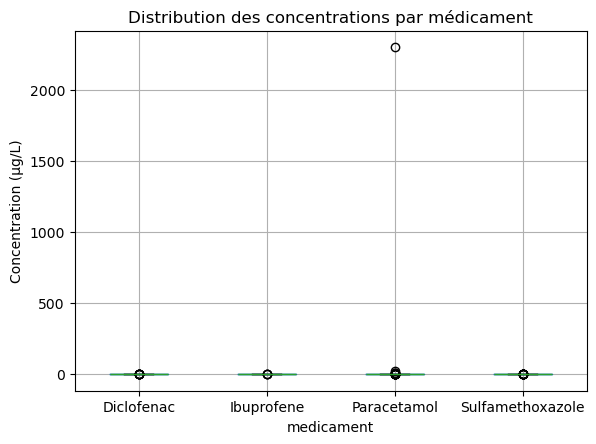

In [27]:
import matplotlib.pyplot as plt

df_quantif.boxplot(column="concentration", by="medicament")

plt.title("Distribution des concentrations par médicament")
plt.suptitle("")
plt.ylabel("Concentration (µg/L)")

plt.show()

Gestion des valeurs extrêmes

L’analyse exploratoire a mis en évidence une valeur extrêmement élevée de concentration en paracétamol (2300 µg/L),
très supérieure aux autres observations du jeu de données.

Afin d’éviter une distorsion des statistiques descriptives, cette valeur a été considérée comme un outlier et exclue des analyses globales. 
Les données brutes ont néanmoins été conservées dans le jeu de données initial.

# base sans outliers extrêmes

In [28]:
df_sans_outlier = df_quantif[
    df_quantif["concentration"] < 100
].copy()

# Concentration moyenne par médicament

In [29]:
df_sans_outlier.groupby("medicament")["concentration"] \
    .mean() \
    .sort_values(ascending=False)

medicament
Paracetamol         0.760045
Ibuprofene          0.096821
Diclofenac          0.081773
Sulfamethoxazole    0.046229
Name: concentration, dtype: float64

# Concentration max par médicament

In [30]:
df_sans_outlier.groupby("medicament")["concentration"] \
    .max() \
    .sort_values(ascending=False)

medicament
Paracetamol         21.000
Diclofenac           0.511
Ibuprofene           0.463
Sulfamethoxazole     0.330
Name: concentration, dtype: float64

# Communes avec concentrations élevées

In [31]:
df_quantif.groupby("commune")["concentration"] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

commune
Terrasson-Lavilledieu        766.681333
Bourganeuf                     4.371000
Saint-Antoine-sur-l'Isle       3.512500
Saint-Denis-des-Murs           3.325000
Langon                         3.141375
Saint-Genès-de-Lombaud         2.289500
Saint-Pantaléon-de-Larche      1.893800
Frontenay-Rohan-Rohan          1.774000
Calès                          1.000000
Azay-sur-Thouet                0.964000
Name: concentration, dtype: float64

In [32]:
df_sans_outlier["annee"] = df_sans_outlier["date_prelevement"].dt.year

df_sans_outlier.groupby("annee")["concentration"] \
    .mean()

annee
2015    0.236714
2016    0.389000
2017    0.358489
2018    0.417200
2019    0.196658
2020    0.304923
2021    0.241919
2022    0.601910
2023    0.293867
2024    0.343334
Name: concentration, dtype: float64

In [101]:
# Sauvegarde de  et exportation de la base
df_sans_outlier.to_csv("donnees_medicaments_nouvelle_aquitaine_clean.csv", index=False)

In [102]:
df_sans_outlier.tail()

,code_station,station,commune,region,CodeDepartement,departement,x,y,date_prelevement,medicament,concentration,unite,qualite_analyse,remarque_analyse,annee
1570,05238500,La Bidassoa à Biriatou,Biriatou,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,315429.0,6259610.0,2020-07-21,Ibuprofene,0.331,µg/L,Correcte,Domaine de validité,2020
1571,05238500,La Bidassoa à Biriatou,Biriatou,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,315429.0,6259610.0,2020-09-15,Sulfamethoxazole,0.006,µg/L,Correcte,Domaine de validité,2020
1572,05238500,La Bidassoa à Biriatou,Biriatou,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,315429.0,6259610.0,2022-09-20,Sulfamethoxazole,0.010,µg/L,Correcte,Domaine de validité,2022
1624,Q3325003,Barrage de l'Ayguelongue,Mazerolles,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,419398.0,6265457.0,2017-06-01,Ibuprofene,0.010,µg/L,Correcte,Domaine de validité,2017
1625,Q3325003,Barrage de l'Ayguelongue,Mazerolles,Nouvelle-Aquitaine,64,Pyrénées-Atlantiques,419398.0,6265457.0,2017-10-05,Ibuprofene,0.010,µg/L,Correcte,Domaine de validité,2017
